In [1]:
import os

dataset_path = "brain_tumor_dataset"

yes_path = os.path.join(dataset_path, "yes")
no_path = os.path.join(dataset_path, "no")

yes_count = len([
    f for f in os.listdir(yes_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

no_count = len([
    f for f in os.listdir(no_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

total = yes_count + no_count

print("="*40)
print("DATASET SUMMARY")
print("="*40)
print(f"Tumor Images (YES): {yes_count}")
print(f"Non-Tumor Images (NO): {no_count}")
print(f"Total Images: {total}")
print("="*40)

DATASET SUMMARY
Tumor Images (YES): 155
Non-Tumor Images (NO): 98
Total Images: 253


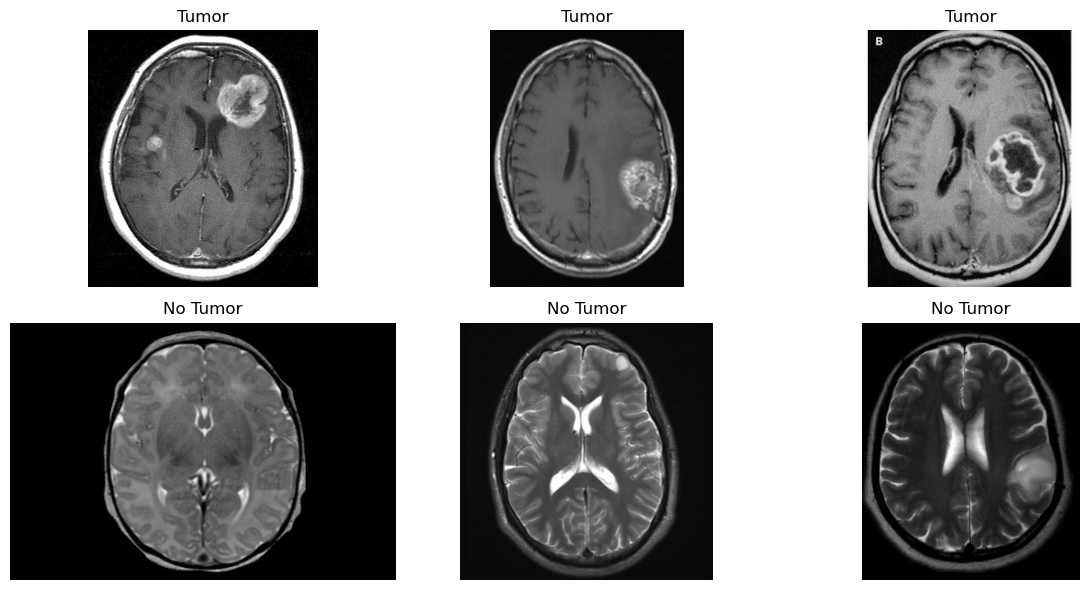

In [2]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = "brain_tumor_dataset"

yes_path = os.path.join(dataset_path, "yes")
no_path = os.path.join(dataset_path, "no")

yes_images = os.listdir(yes_path)
no_images = os.listdir(no_path)

plt.figure(figsize=(12,6))

# Show 3 tumor images
for i in range(3):
    img_name = random.choice(yes_images)
    img = Image.open(os.path.join(yes_path, img_name))

    plt.subplot(2,3,i+1)
    plt.imshow(img, cmap='gray')
    plt.title("Tumor")
    plt.axis("off")

# Show 3 non-tumor images
for i in range(3):
    img_name = random.choice(no_images)
    img = Image.open(os.path.join(no_path, img_name))

    plt.subplot(2,3,i+4)
    plt.imshow(img, cmap='gray')
    plt.title("No Tumor")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [3]:
import os
from PIL import Image

dataset_path = "brain_tumor_dataset"

yes_path = os.path.join(dataset_path, "yes")
no_path = os.path.join(dataset_path, "no")

sample_yes = os.listdir(yes_path)[0]
sample_no = os.listdir(no_path)[0]

img_yes = Image.open(os.path.join(yes_path, sample_yes))
img_no = Image.open(os.path.join(no_path, sample_no))

print("Tumor Image")
print("Size:", img_yes.size)
print("Mode:", img_yes.mode)

print("\n----------------------\n")

print("Non-Tumor Image")
print("Size:", img_no.size)
print("Mode:", img_no.mode)

Tumor Image
Size: (180, 218)
Mode: RGB

----------------------

Non-Tumor Image
Size: (630, 630)
Mode: L


In [4]:
import os
from PIL import Image

dataset_path = "brain_tumor_dataset"

widths = []
heights = []
modes = {}

for category in ["yes", "no"]:
    folder = os.path.join(dataset_path, category)

    for file in os.listdir(folder):

        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            try:
                img = Image.open(os.path.join(folder, file))

                widths.append(img.size[0])
                heights.append(img.size[1])

                mode = img.mode

                if mode not in modes:
                    modes[mode] = 0

                modes[mode] += 1

            except:
                pass

print("DATASET ANALYSIS")
print("="*40)

print("Minimum Width :", min(widths))
print("Maximum Width :", max(widths))

print()

print("Minimum Height:", min(heights))
print("Maximum Height:", max(heights))

print()

print("Image Modes:")
print(modes)

DATASET ANALYSIS
Minimum Width : 150
Maximum Width : 1920

Minimum Height: 168
Maximum Height: 1427

Image Modes:
{'RGB': 217, 'L': 30, 'RGBA': 5, 'P': 1}


In [5]:
import os
from PIL import Image

dataset_path = "brain_tumor_dataset"

processed_path = "processed_dataset"

for category in ["yes", "no"]:

    input_folder = os.path.join(dataset_path, category)
    output_folder = os.path.join(processed_path, category)

    os.makedirs(output_folder, exist_ok=True)

    count = 0

    for file in os.listdir(input_folder):

        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            try:
                img_path = os.path.join(input_folder, file)

                img = Image.open(img_path)

                # Convert all images to RGB
                img = img.convert("RGB")

                # Resize to VGG standard size
                img = img.resize((224, 224))

                save_path = os.path.join(output_folder, file)

                img.save(save_path)

                count += 1

            except Exception as e:
                print("Error:", file, e)

    print(f"{category}: {count} images processed")

print("\nPreprocessing Complete")

yes: 155 images processed
no: 98 images processed

Preprocessing Complete


In [6]:
from PIL import Image
import os

sample = os.listdir("processed_dataset/yes")[0]

img = Image.open(os.path.join("processed_dataset/yes", sample))

print("Size:", img.size)
print("Mode:", img.mode)

Size: (224, 224)
Mode: RGB


In [7]:
import os
import numpy as np
from PIL import Image

X = []
y = []

dataset_path = "processed_dataset"

for category in ["yes", "no"]:

    folder = os.path.join(dataset_path, category)

    label = 1 if category == "yes" else 0

    for file in os.listdir(folder):

        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            img = Image.open(os.path.join(folder, file))

            img_array = np.array(img)

            X.append(img_array)
            y.append(label)

X = np.array(X)
y = np.array(y)

print("Images Shape :", X.shape)
print("Labels Shape :", y.shape)

Images Shape : (253, 224, 224, 3)
Labels Shape : (253,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

print()

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Images : (202, 224, 224, 3)
Testing Images  : (51, 224, 224, 3)

Training Labels : (202,)
Testing Labels  : (51,)


In [9]:
import numpy as np

print("TRAINING SET")
unique, counts = np.unique(y_train, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

print("\nTESTING SET")

unique, counts = np.unique(y_test, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

TRAINING SET
Class 0: 78
Class 1: 124

TESTING SET
Class 0: 20
Class 1: 31


In [10]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training Range")
print("Min:", X_train.min())
print("Max:", X_train.max())

print("\nTesting Range")
print("Min:", X_test.min())
print("Max:", X_test.max())

Training Range
Min: 0.0
Max: 1.0

Testing Range
Min: 0.0
Max: 1.0


In [11]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

cnn_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )

])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=16,
    verbose=1
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 559ms/step - accuracy: 0.6683 - loss: 0.7696 - val_accuracy: 0.7647 - val_loss: 0.5572
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 540ms/step - accuracy: 0.7525 - loss: 0.5610 - val_accuracy: 0.7843 - val_loss: 0.4356
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 539ms/step - accuracy: 0.8069 - loss: 0.4722 - val_accuracy: 0.7843 - val_loss: 0.4299
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 544ms/step - accuracy: 0.8218 - loss: 0.4410 - val_accuracy: 0.8235 - val_loss: 0.3678
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 561ms/step - accuracy: 0.8663 - loss: 0.3543 - val_accuracy: 0.8431 - val_loss: 0.3120
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 547ms/step - accuracy: 0.8911 - loss: 0.2606 - val_accuracy: 0.8431 - val_loss: 0.3255
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 556ms/step - accuracy: 0.9010 - loss: 0.2446 - val_accuracy: 0.8824 - val_loss: 0.2985
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 559ms/step - accuracy: 0.9406 - loss: 0.1863 - val_accuracy: 0.

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Predict
y_pred_prob = cnn_model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 487ms/step
Accuracy : 0.9216
Precision: 0.9091
Recall   : 0.9677
F1 Score : 0.9375

Confusion Matrix
[[17  3]
 [ 1 30]]


In [15]:
cnn_model.save("cnn_baseline_model.h5")

print("CNN model saved successfully")

CNN model saved successfully


In [16]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [17]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Flatten,
    Dense,
    Dropout
)

# Load pretrained VGG16
vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze pretrained layers
for layer in vgg_base.layers:
    layer.trainable = False

# Build model
vgg16_model = Sequential([
    vgg_base,

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )
])

vgg16_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

vgg16_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,209 (68.38 MB)

 Trainable params: 3,211,521 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [18]:
history_vgg16 = vgg16_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=16,
    verbose=1
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.6386 - loss: 1.3185 - val_accuracy: 0.8431 - val_loss: 0.4631
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.7574 - loss: 0.7370 - val_accuracy: 0.8627 - val_loss: 0.3321
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.8020 - loss: 0.4134 - val_accuracy: 0.8431 - val_loss: 0.3019
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.8911 - loss: 0.3111 - val_accuracy: 0.8824 - val_loss: 0.2495
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.8960 - loss: 0.2824 - val_accuracy: 0.9020 - val_loss: 0.2475
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9406 - loss: 0.1989 - val_accuracy: 0.9020 - val_loss: 0.2262
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9307 - loss: 0.1752 - val_accuracy: 0.9216 - val_loss: 0.2073
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9307 - loss: 0.1769 - val_accuracy: 0.9216 - val_loss:

In [19]:
test_loss_vgg16, test_acc_vgg16 = vgg16_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("VGG16 Test Accuracy:", round(test_acc_vgg16 * 100, 2), "%")
print("VGG16 Test Loss:", round(test_loss_vgg16, 4))

VGG16 Test Accuracy: 90.2 %
VGG16 Test Loss: 0.2112


In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_pred_prob_vgg16 = vgg16_model.predict(X_test)

y_pred_vgg16 = (y_pred_prob_vgg16 > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred_vgg16)
precision = precision_score(y_test, y_pred_vgg16)
recall = recall_score(y_test, y_pred_vgg16)
f1 = f1_score(y_test, y_pred_vgg16)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_vgg16))

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step
Accuracy : 0.902
Precision: 0.9062
Recall   : 0.9355
F1 Score : 0.9206

Confusion Matrix
[[17  3]
 [ 2 29]]


In [21]:
vgg16_model.save("vgg16_model.h5")

print("VGG16 model saved successfully")

VGG16 model saved successfully


In [22]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Flatten,
    Dense,
    Dropout
)

vgg19_base = VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in vgg19_base.layers:
    layer.trainable = False

vgg19_model = Sequential([
    vgg19_base,

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )
])

vgg19_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

vgg19_model.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,235,905 (88.64 MB)

 Trainable params: 3,211,521 (12.25 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [23]:
history_vgg19 = vgg19_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=16,
    verbose=1
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 54s 4s/step - accuracy: 0.6238 - loss: 1.6861 - val_accuracy: 0.7647 - val_loss: 0.5395
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 52s 4s/step - accuracy: 0.7426 - loss: 0.7747 - val_accuracy: 0.7843 - val_loss: 0.5034
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 51s 4s/step - accuracy: 0.7970 - loss: 0.4785 - val_accuracy: 0.8039 - val_loss: 0.3368
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 52s 4s/step - accuracy: 0.8416 - loss: 0.3470 - val_accuracy: 0.8235 - val_loss: 0.3118
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 52s 4s/step - accuracy: 0.8317 - loss: 0.3349 - val_accuracy: 0.8235 - val_loss: 0.3092
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 52s 4s/step - accuracy: 0.8218 - loss: 0.3753 - val_accuracy: 0.8431 - val_loss: 0.3008
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 51s 4s/step - accuracy: 0.8317 - loss: 0.3540 - val_accuracy: 0.8431 - val_loss: 0.3200
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 51s 4s/step - accuracy: 0.8911 - loss: 0.2908 - val_accuracy: 0.8235 - val_loss:

In [24]:
test_loss_vgg19, test_acc_vgg19 = vgg19_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("VGG19 Test Accuracy:", round(test_acc_vgg19 * 100, 2), "%")
print("VGG19 Test Loss:", round(test_loss_vgg19, 4))

VGG19 Test Accuracy: 92.16 %
VGG19 Test Loss: 0.2493


In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_pred_prob_vgg19 = vgg19_model.predict(X_test)

y_pred_vgg19 = (y_pred_prob_vgg19 > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred_vgg19)
precision = precision_score(y_test, y_pred_vgg19)
recall = recall_score(y_test, y_pred_vgg19)
f1 = f1_score(y_test, y_pred_vgg19)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_vgg19))

1/2 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001D3870D25C0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step
Accuracy : 0.9216
Precision: 0.9655
Recall   : 0.9032
F1 Score : 0.9333

Confusion Matrix
[[19  1]
 [ 3 28]]


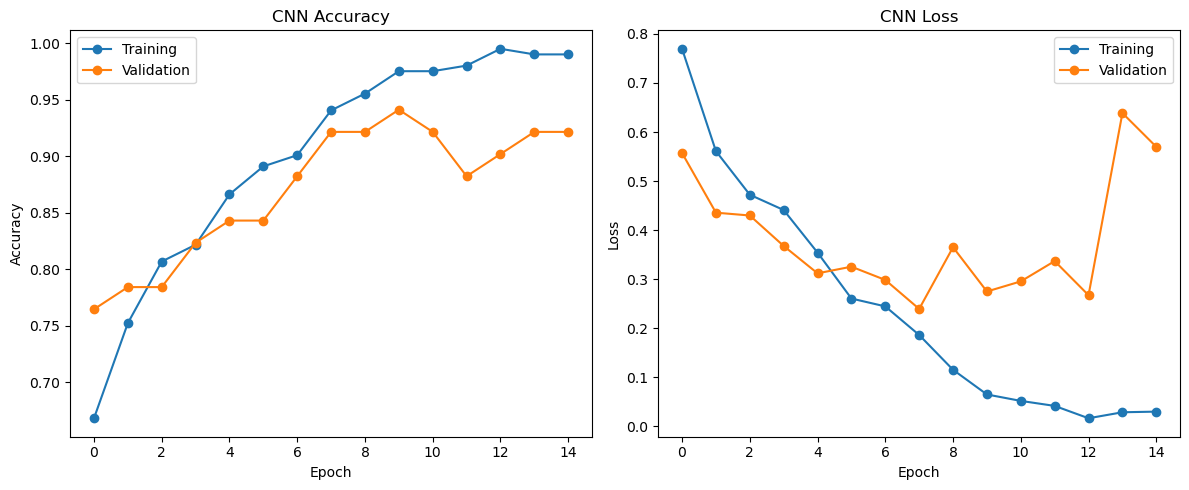

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training','Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training','Validation'])

plt.tight_layout()
plt.show()

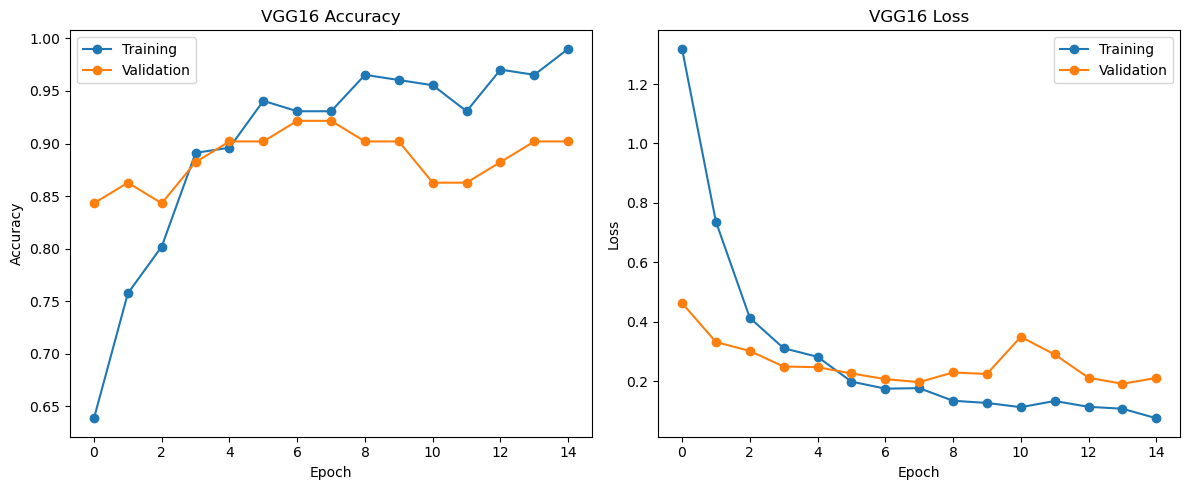

In [27]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_vgg16.history['accuracy'], marker='o')
plt.plot(history_vgg16.history['val_accuracy'], marker='o')
plt.title('VGG16 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training','Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(history_vgg16.history['loss'], marker='o')
plt.plot(history_vgg16.history['val_loss'], marker='o')
plt.title('VGG16 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training','Validation'])

plt.tight_layout()
plt.show()

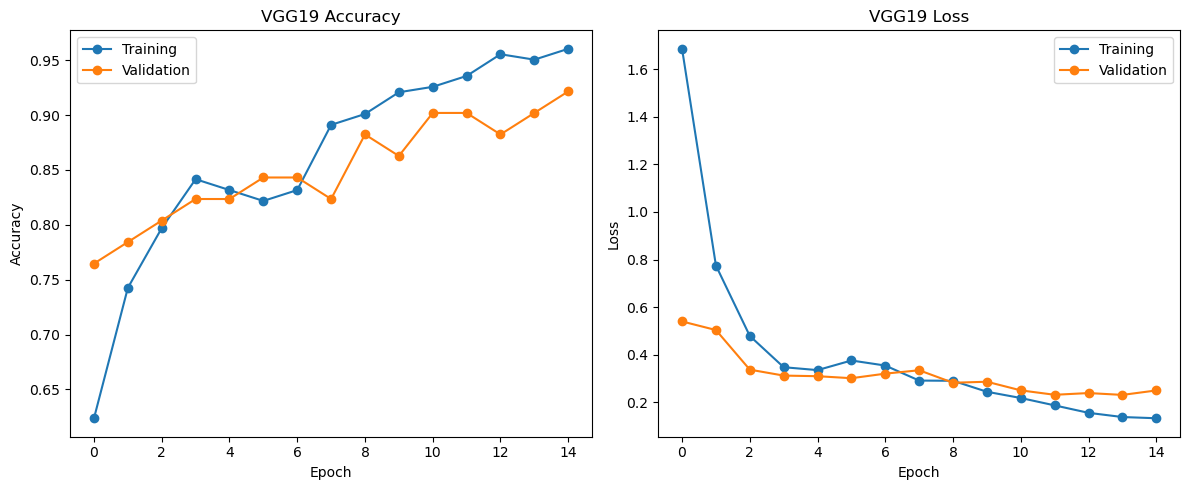

In [28]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_vgg19.history['accuracy'], marker='o')
plt.plot(history_vgg19.history['val_accuracy'], marker='o')
plt.title('VGG19 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training','Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(history_vgg19.history['loss'], marker='o')
plt.plot(history_vgg19.history['val_loss'], marker='o')
plt.title('VGG19 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training','Validation'])

plt.tight_layout()
plt.show()

In [29]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["CNN", "VGG16", "VGG19"],
    "Accuracy": [90.20, 90.20, 92.16],
    "Precision": [88.24, 93.33, 96.55],
    "Recall": [96.77, 90.32, 90.32],
    "F1 Score": [92.31, 91.80, 93.33]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,CNN,90.20,88.24,96.77,92.31
1,VGG16,90.20,93.33,90.32,91.80
2,VGG19,92.16,96.55,90.32,93.33


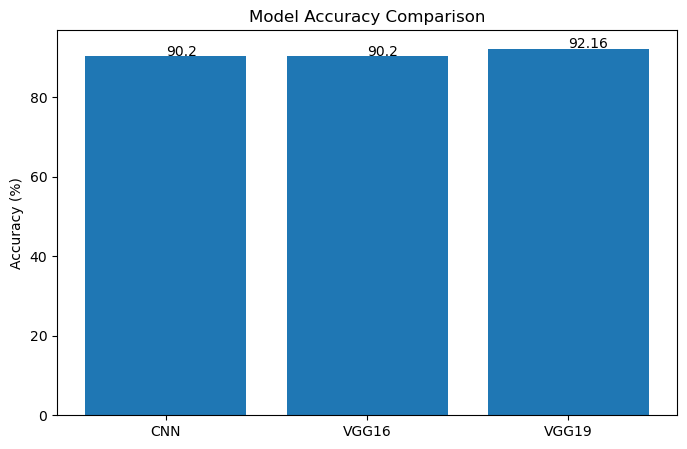

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")

for i, v in enumerate(results["Accuracy"]):
    plt.text(i, v + 0.2, str(v))

plt.show()

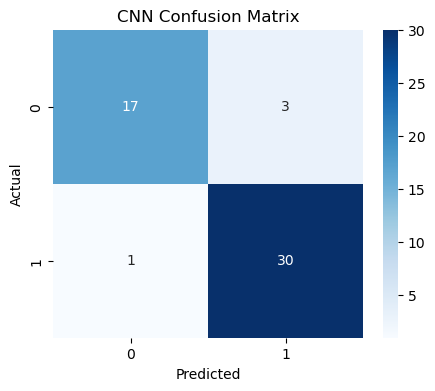

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# CNN
cm_cnn = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_cnn,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

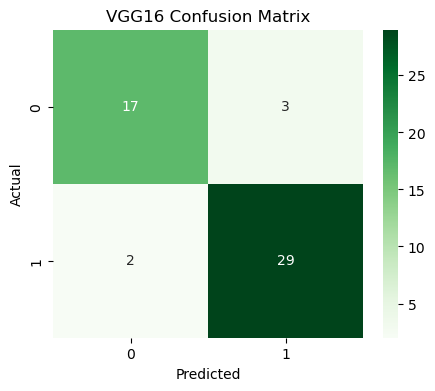

In [32]:
cm_vgg16 = confusion_matrix(y_test, y_pred_vgg16)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_vgg16,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

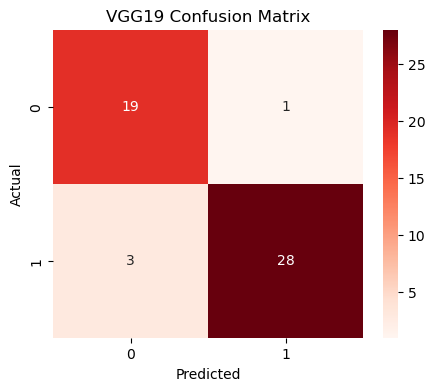

In [33]:
cm_vgg19 = confusion_matrix(y_test, y_pred_vgg19)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_vgg19,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("VGG19 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [34]:
vgg19_model.save("best_brain_tumor_model.h5")

print("Best model saved successfully")

Best model saved successfully


In [35]:
import sys
print(sys.executable)

c:\ProgramData\anaconda3\python.exe
